In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
bank=pd.read_csv('subscription_prediction.xls')

In [ ]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,57,housemaid,divorced,basic.4y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,39,management,single,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
pd.set_option('display.max_columns',None)


In [ ]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,57,housemaid,divorced,basic.4y,no,yes,no,telephone,may,mon,293,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,39,management,single,basic.9y,unknown,no,no,telephone,may,mon,195,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
bank['contact'].unique()

array(['telephone', 'cellular'], dtype=object)

In [ ]:
bank['pdays'].unique()

array([999,   6,   4,   5,  10,   7,   1,  11,   9,   2,   0,   3,  12,
        13,  14,  15,  16,   8,  21,  18,  22,  25,  26,  17,  27,  19])

In [ ]:
bank['previous'].unique()

array([0, 1, 2, 3, 4, 5, 6])

In [ ]:
bank['poutcome'].unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [ ]:
bank['emp.var.rate'].unique()

array([ 1.1,  1.4, -0.1, -0.2, -1.8, -2.9, -3.4, -3. , -1.7, -1.1])

In [ ]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10122 entries, 0 to 10121
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10122 non-null  int64  
 1   job             10122 non-null  object 
 2   marital         10122 non-null  object 
 3   education       10122 non-null  object 
 4   default         10122 non-null  object 
 5   housing         10122 non-null  object 
 6   loan            10122 non-null  object 
 7   contact         10122 non-null  object 
 8   month           10122 non-null  object 
 9   day_of_week     10122 non-null  object 
 10  duration        10122 non-null  int64  
 11  campaign        10122 non-null  int64  
 12  pdays           10122 non-null  int64  
 13  previous        10122 non-null  int64  
 14  poutcome        10122 non-null  object 
 15  emp.var.rate    10122 non-null  float64
 16  cons.price.idx  10122 non-null  float64
 17  cons.conf.idx   10122 non-null 

In [ ]:
bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

**age:** (numeric)




**job:** type of job (categorical: 'admin','blue collar','entrepreneur','housemaid','management','retired','self employed','services','student','technician','unemployed','unknown')




**marital:** marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)




**education:** (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')




**default:** has credit in default? (categorical: 'no','yes','unknown')

*   List item
*   List item





**housing:** has housing loan? (categorical: 'no','yes','unknown')




**loan:** has personal loan? (categorical: 'no','yes','unknown')




**contact:** contact communication type (categorical: 'cellular','telephone')




**month:** last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')




**day_of_week:** last contact day of the week (categorical: 'mon','tue','wed','thu','fri')




**duration:** last contact duration, in seconds (numeric).




**campaign:** number of contacts performed during this campaign and for this client (numeric, includes last contact)




**pdays:** number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)




**previous:** number of contacts performed before this campaign and for this client (numeric)




**poutcome:** outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')




**emp.var.rate:** employment variation rate - quarterly indicator (numeric)




**cons.price.idx:** consumer price index - monthly indicator (numeric)




**cons.conf.idx:** consumer confidence index - monthly indicator (numeric)




**euribor3m:** euribor 3 month rate - daily indicator (numeric)




**nr.employed:** number of employees - quarterly indicator (numeric)




**y**: has the client subscribed a term deposit? (binary: 'yes','no')

In [ ]:
bank.dtypes.value_counts()

,count
object,11
int64,5
float64,5


In [ ]:
bank.select_dtypes("int")

,age,duration,campaign,pdays,previous
0,40,151,1,999,0
1,56,307,1,999,0
2,41,217,1,999,0
3,57,293,1,999,0
4,39,195,1,999,0
...,...,...,...,...,...
10117,64,151,3,999,0
10118,37,281,1,999,0
10119,73,334,1,999,0
10120,44,442,1,999,0


In [ ]:
bank['y']=bank["y"].apply(lambda x: 1 if x=="yes" else 0)

In [ ]:
bank["y"].unique()

array([0, 1])

In [ ]:
train_data=bank.sample(frac=.85,random_state=417)

In [ ]:
train_data.shape

(8604, 21)

In [ ]:
bank.shape

(10122, 21)

To check if the train data is correctly select or not....we will check the proportions from both bank and train data.

In [ ]:
bank["y"].value_counts(normalize=True)

,proportion
y,
0,0.541593
1,0.458407


In [ ]:
train_data["y"].value_counts(normalize=True)

,proportion
y,
0,0.540098
1,0.459902


Here ....droping the index value of train data from bank data gives test data

In [ ]:
test_data=bank.drop(train_data.index)

In [ ]:
test_data.shape

(1518, 21)

In [ ]:
X_train=train_data.drop("y",axis=1)

In [ ]:
y_train=train_data["y"]

In [ ]:
X_test=test_data.drop("y",axis=1)
y_test=test_data["y"]

In [ ]:
#X_train

In [ ]:
#y_train

In [ ]:
## K is no. of nearest data helps us to predict
def Knn(feature,single_row,k):
  diff=X_train[feature]-single_row[feature]
  smallest_k=diff.nsmallest(k)
  pred=y_train[smallest_k.index].mode()[0]
  return pred

In [ ]:
Knn("age",X_train.iloc[30],5)

np.int64(1)

In [ ]:
y_pred=X_test.apply(lambda x: Knn("age",x,5),axis=1)

In [ ]:
(y_test==y_pred).sum()/len(y_test)*100

np.float64(44.99341238471673)

In [ ]:
def Knn(feature,single_row,k):
  diff=X_train[feature]-single_row[feature]
  smallest_k=diff.nsmallest(k)
  pred=y_train[smallest_k.index].mode()
  return pred

In [ ]:
Knn("age",X_train.iloc[30],5)

,y
0,1


The martial state is in string - so we want to convert the dtype into numerical data ..we ***can't randomly convert the data*** like , (single - 0, Married- 1,Divorced-2, Unknown- 3) , So if we calculate for age 10 it will subtract their value from the age ; like-> 10-0 for single =10, 10-1 for married=9, 10-2 for Divorced =8, 10-3 for Unknown= 8 , therefore model will take smallest value ..so it will choose the data for single ..therefore , it will **create biasness** ...***To avoid Biasness*** , we will **use One-hot encoding**.

**improved version of one hot encoding** : if n categoried then use n-1 categories

Multicolinearity-

Multidimensionality-

In [ ]:
bank_copy=pd.get_dummies(bank,columns=["marital"],drop_first=True)

In [ ]:
train_data_c=bank_copy.sample(frac=.85,random_state=417)
test_data_c=bank_copy.drop(train_data_c.index)

In [ ]:
X_train_c=train_data_c.drop("y",axis=1)
y_train_c=train_data_c["y"]
X_test_c=test_data_c.drop("y",axis=1)
y_test_c=test_data_c["y"]

In [ ]:
X_train_c.columns

Index(['age', 'job', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'marital_married', 'marital_single',
       'marital_unknown'],
      dtype='object')

In [ ]:
def knn_2(features,single_input,k):
  squared_distance=0
  for feature in features:
    squared_distance+=(X_train_c[feature].astype("float")-float(single_input[feature]))**2
  X_train_c["distance"]=np.sqrt(squared_distance)
  smallest_k=X_train_c["distance"].nsmallest(k)
  pred=y_train_c[smallest_k.index].mode()[0]
  return pred

In [ ]:
X_train_c.columns


Index(['age', 'job', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'marital_married', 'marital_single',
       'marital_unknown'],
      dtype='object')

In [ ]:
knn_2(["age",'marital_married', 'marital_single'],X_test_c.iloc[20],4)

np.int64(0)

In [ ]:
y_pred_c=X_test_c.apply(lambda x: knn_2(["age",'marital_married', 'marital_single'],x,4),axis=1)

In [ ]:
(y_test_c==y_pred_c).sum()/len(y_test_c)*100

np.float64(57.11462450592886)

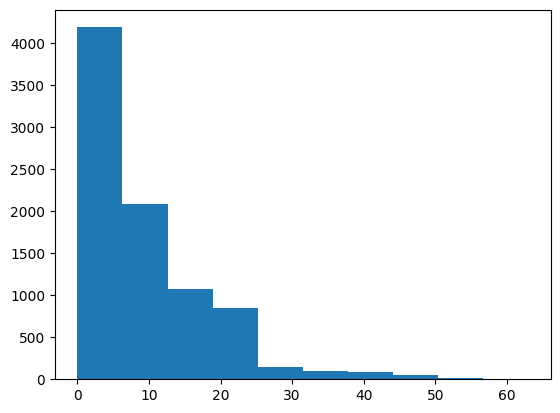

In [ ]:
plt.hist(X_train_c["distance"])
plt.show()

In [ ]:
min_1=bank_copy["nr.employed"].min()
max_1=bank_copy["nr.employed"].max()
X_train_c["nr.employed"]=(X_train_c["nr.employed"]-min_1)/(max_1-min_1)
X_test_c["nr.employed"]=(X_test_c["nr.employed"]-min_1)/(max_1-min_1)
min_2=bank_copy["age"].min()
max_2=bank_copy["age"].max()
X_train_c["age"]=(X_train_c["age"]-min_2)/(max_2-min_2)
X_test_c["age"]=(X_test_c["age"]-min_2)/(max_2-min_2)

In [ ]:
def knn_2(features,single_input,k):
  squared_distance=0
  for feature in features:
    squared_distance+=(X_train_c[feature].astype("float")-float(single_input[feature]))**2
  X_train_c["distance"]=np.sqrt(squared_distance)
  smallest_k=X_train_c["distance"].nsmallest(k)
  pred=y_train_c[smallest_k.index].mode()[0]
  return pred

In [ ]:
knn_2(['age', 'marital_married', "nr.employed",'duration'],X_test_c.iloc[20],4)

np.int64(1)

In [ ]:
y_pred_c=X_test_c.apply(lambda x: knn_2(['age','marital_married','nr.employed','duration'],x,4),axis=1)

In [ ]:
(y_test_c==y_pred_c).sum()/len(y_test_c)*100

np.float64(69.96047430830039)

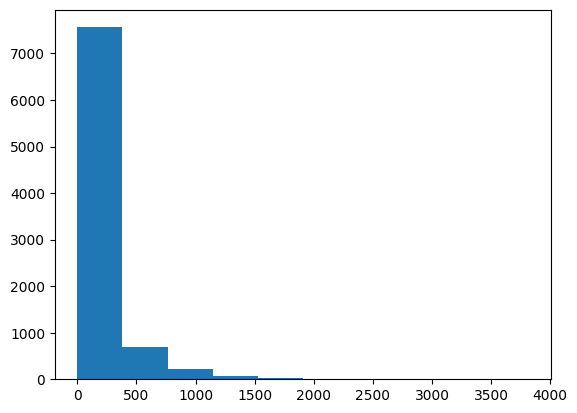

In [ ]:
plt.hist(X_train_c["distance"])
plt.show()